# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [306]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [307]:
df = pd.read_csv(r"C:\Users\Rafael\Downloads\Cursos\Ebac\Curso de Ciencia de Dados\12 - Pre - Modelagem\CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [308]:
df.info()

print('\n')
espaco = 100 * '-'
print(espaco)
print('\n')

df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customerID          2500 non-null   object 
 1   Genero              2488 non-null   object 
 2   Idoso               2500 non-null   int64  
 3   Casado              2500 non-null   object 
 4   Dependents          2500 non-null   object 
 5   Tempo_como_Cliente  2500 non-null   int64  
 6   PhoneService        1018 non-null   object 
 7   Servico_Internet    2500 non-null   object 
 8   Servico_Seguranca   2500 non-null   object 
 9   Suporte_Tecnico     2500 non-null   object 
 10  StreamingTV         2500 non-null   object 
 11  Tipo_Contrato       2500 non-null   object 
 12  PaymentMethod       2500 non-null   object 
 13  Pagamento_Mensal    2175 non-null   float64
 14  Total_Pago          2500 non-null   float64
 15  Churn               2495 non-null   object 
dtypes: flo

customerID             object
Genero                 object
Idoso                   int64
Casado                 object
Dependents             object
Tempo_como_Cliente      int64
PhoneService           object
Servico_Internet       object
Servico_Seguranca      object
Suporte_Tecnico        object
StreamingTV            object
Tipo_Contrato          object
PaymentMethod          object
Pagamento_Mensal      float64
Total_Pago            float64
Churn                  object
dtype: object

In [309]:
df['Idoso'] = df['Idoso'].apply(str)

print(df['Idoso'].dtype)

df['Idoso'] = df['Idoso'].map({'0': 'No', '1': 'Yes'})

object


# 2 - Esse exercício faremos por etapas:
A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [310]:
valores_nulos = df.isnull().sum()

porcentagem_nulos = (df.isnull().sum() / len(df)) * 100

tabela_faltantes = pd.DataFrame({
    'Total de Nulos': valores_nulos,
    'Porcentagem (%)': porcentagem_nulos
})

tabela_faltantes = tabela_faltantes[tabela_faltantes['Total de Nulos'] > 0].sort_values(by='Total de Nulos', ascending=False)

tabela_faltantes

,Total de Nulos,Porcentagem (%)
PhoneService,1482,59.28
Pagamento_Mensal,325,13.00
Genero,12,0.48
Churn,5,0.20


B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

In [311]:
# # Decide excluir o dados da coluna Genero e da coluna Churn, pois a porcentagem de dados
# nulos dessas duas colunas sao minusculas, entao creio que nao vai fazer tanta diferença ou 
# ter um impacto negativo a exclusao dos dados dessas duas colunas.

# # Os dados nulos da coluna PhoneService, ao inves de simplesmente excluir, como eles 
# eram do tipo str e tinha uma porcentagem muito alta quase 60% e nao eram do tipo int
# eu renomeie esses dados nulos como dados, ('No Informed') Dados que nao foram informados.

In [312]:
df = df.dropna(subset=['Genero', 'Churn'])

In [313]:
df['PhoneService'] = df['PhoneService'].fillna('No Informed')

In [314]:
valores_nulos = df.isnull().sum()

porcentagem_nulos = (df.isnull().sum() / len(df)) * 100

tabela_faltantes = pd.DataFrame({
    'Total de Nulos': valores_nulos,
    'Porcentagem (%)': porcentagem_nulos
})

tabela_faltantes = tabela_faltantes[tabela_faltantes['Total de Nulos'] > 0].sort_values(by='Total de Nulos', ascending=False)

tabela_faltantes

,Total de Nulos,Porcentagem (%)
Pagamento_Mensal,313,12.580386


In [315]:
df.to_csv(r"C:\Users\Rafael\Downloads\Cursos\Ebac\Curso de Ciencia de Dados\12 - Pre - Modelagem\CHURN_TELECON_MOD08_TAREFA_ATUALIZADO.csv", sep=';', index=False)

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
16,8191-XWSZG,F,No,No,No,52,Yes,No,No internet service,No internet service,No internet service,One year,Mailed check,NaN,1022.95,No
17,9959-WOFKT,Male,No,No,Yes,71,Yes,Fiber optic,Yes,No,Yes,Two year,Bank transfer (automatic),NaN,7382.25,No
18,4190-MFLUW,F,No,Yes,Yes,10,Yes,DSL,No,Yes,No,Month-to-month,Credit card (automatic),NaN,528.35,Yes
19,4183-MYFRB,F,No,No,No,21,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,1862.90,No
20,8779-QRDMV,Male,Yes,No,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,NaN,39.65,Yes
21,1680-VDCWW,Male,No,Yes,No,12,Yes,No,No internet service,No internet service,No internet service,One year,Bank transfer (automatic),NaN,202.25,No


C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [316]:
# Optei por usar o valor da mediana aos inves do valor da media e da moda, a moda está com um valor muito baixo, isso poderia vir a causar
# um vies na minha analise, e a media e a mediana estavam com um valor aproximado, decidi usar a mediana por ela estar com um valor mais robusto.

In [317]:
df['Pagamento_Mensal'].agg(['mean', 'median', lambda x: x.mode()[0]])

mean        65.607563
median      71.450000
<lambda>    20.050000
Name: Pagamento_Mensal, dtype: float64

C:\Users\Rafael\AppData\Local\Temp\ipykernel_11236\677180381.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Métrica', y='Valor (R$)', data=df_plot, palette='Blues_r')


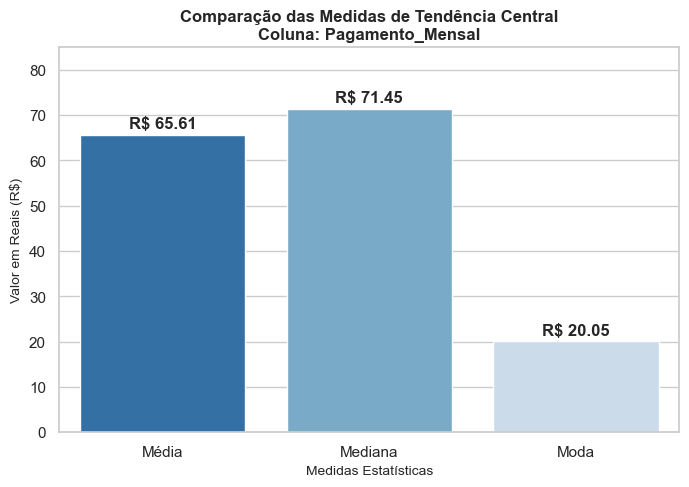

In [318]:
dados_metricas = {
    'Métrica': ['Média', 'Mediana', 'Moda'],
    'Valor (R$)': [65.607563, 71.450000, 20.050000]
}
df_plot = pd.DataFrame(dados_metricas)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Métrica', y='Valor (R$)', data=df_plot, palette='Blues_r')
for p in ax.patches:
    ax.annotate(f"R$ {p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points', 
                fontweight='bold')

plt.title('Comparação das Medidas de Tendência Central\nColuna: Pagamento_Mensal', fontsize=12, fontweight='bold')
plt.xlabel('Medidas Estatísticas', fontsize=10)
plt.ylabel('Valor em Reais (R$)', fontsize=10)
plt.ylim(0, 85)
plt.show()

In [319]:
mediana_pagamento = df['Pagamento_Mensal'].median()
df['Pagamento_Mensal'] = df['Pagamento_Mensal'].fillna(mediana_pagamento)

print("Nulos restantes em Pagamento_Mensal:", df['Pagamento_Mensal'].isna().sum())

Nulos restantes em Pagamento_Mensal: 0


# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [320]:
colunas_texto = [
    'Genero', 'Casado', 'Dependents', 'PhoneService', 'Servico_Internet', 
    'Servico_Seguranca', 'Suporte_Tecnico', 'StreamingTV', 
    'Tipo_Contrato', 'PaymentMethod', 'Churn'
]
for col in colunas_texto:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.capitalize()
for col in colunas_texto:
    if col in df.columns:
        print(f"--- Distribuição da coluna: {col} ---")
        print(df[col].value_counts())
        print("\n")

--- Distribuição da coluna: Genero ---
Genero
Male      1265
Female    1212
F            7
M            4
Name: count, dtype: int64


--- Distribuição da coluna: Casado ---
Casado
No     1262
Yes    1226
Name: count, dtype: int64


--- Distribuição da coluna: Dependents ---
Dependents
No     1705
Yes     783
Name: count, dtype: int64


--- Distribuição da coluna: PhoneService ---
PhoneService
No informed    1482
Yes             920
No               86
Name: count, dtype: int64


--- Distribuição da coluna: Servico_Internet ---
Servico_Internet
Fiber optic    1119
Dsl             842
No              527
Name: count, dtype: int64


--- Distribuição da coluna: Servico_Seguranca ---
Servico_Seguranca
No                     1254
Yes                     707
No internet service     527
Name: count, dtype: int64


--- Distribuição da coluna: Suporte_Tecnico ---
Suporte_Tecnico
No                     1250
Yes                     711
No internet service     527
Name: count, dtype: int64


--- Di

In [321]:
regras_genero = {
    'M': 'Masculino',
    'F': 'Feminino',
    'Female': 'Feminino',
    'Male': 'Masculino'
}
df['Genero'] = df['Genero'].replace(regras_genero)
print(df['Genero'].value_counts())

Genero
Masculino    1269
Feminino     1219
Name: count, dtype: int64


# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [324]:
traducao_genero = {'Female': 'Feminino', 'Male': 'Masculino'}
traducao_internet = {'Dsl': 'DSL', 'Fiber optic': 'Fibra Óptica', 'No': 'Não possui'}
traducao_contrato = {'Month-to-month': 'Mensal', 'One year': 'Anual', 'Two year': 'Bienal'}
traducao_pagamento = {
    'Electronic check': 'Cheque Eletrônico', 
    'Mailed check': 'Cheque Correio', 
    'Bank transfer (automatic)': 'Transferência Bancária', 
    'Credit card (automatic)': 'Cartão de Crédito'
}
traducao_servicos = {'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem internet'}

df['Genero'] = df['Genero'].replace(traducao_genero)
df['Servico_Internet'] = df['Servico_Internet'].replace(traducao_internet)
df['Tipo_Contrato'] = df['Tipo_Contrato'].replace(traducao_contrato)
df['PaymentMethod'] = df['PaymentMethod'].replace(traducao_pagamento)

colunas_sim_nao = ['Idoso', 'Casado', 'Dependents', 'PhoneService', 'Churn']
for col in colunas_sim_nao:
    if col in df.columns:
        df[col] = df[col].replace(traducao_sim_nao)

colunas_servicos = ['Servico_Seguranca', 'Suporte_Tecnico', 'StreamingTV']
for col in colunas_servicos:
    if col in df.columns:
        df[col] = df[col].replace(traducao_servicos)
        
df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Feminino,Não,Sim,Não,1,Não,DSL,Não,Não,Não,Mensal,Cheque Eletrônico,29.85,29.85,Não
1,5575-GNVDE,Masculino,Não,Não,Não,34,Sim,DSL,Sim,Não,Não,Anual,Cheque Correio,56.95,1889.50,Não
2,3668-QPYBK,Masculino,Não,Não,Não,2,Sim,DSL,Sim,Não,Não,Mensal,Cheque Correio,53.85,108.15,Sim
3,7795-CFOCW,Masculino,Não,Não,Não,45,Não,DSL,Sim,Sim,Não,Anual,Transferência Bancária,71.45,1840.75,Não
16,8191-XWSZG,Feminino,Não,Não,Não,52,Sim,Não possui,Sem internet,Sem internet,Sem internet,Anual,Cheque Correio,71.45,1022.95,Não
17,9959-WOFKT,Masculino,Não,Não,Sim,71,Sim,Fibra Óptica,Sim,Não,Sim,Bienal,Transferência Bancária,71.45,7382.25,Não
18,4190-MFLUW,Feminino,Não,Sim,Sim,10,Sim,DSL,Não,Sim,Não,Mensal,Cartão de Crédito,71.45,528.35,Sim
19,4183-MYFRB,Feminino,Não,Não,Não,21,Sim,Fibra Óptica,Não,Não,Não,Mensal,Cheque Eletrônico,71.45,1862.90,Não
20,8779-QRDMV,Masculino,Sim,Não,Não,1,Não,DSL,Não,Não,Não,Mensal,Cheque Eletrônico,71.45,39.65,Sim
21,1680-VDCWW,Masculino,Não,Sim,Não,12,Sim,Não possui,Sem internet,Sem internet,Sem internet,Anual,Transferência Bancária,71.45,202.25,Não


In [323]:
traducao_en_sim_nao = {'Sim': 'Yes', 'Não': 'No'}
traducao_en_genero = {'Feminino': 'Female', 'Masculino': 'Male'}
traducao_en_internet = {'DSL': 'Dsl', 'Fibra Óptica': 'Fiber optic', 'Não possui': 'No'}
traducao_en_contrato = {'Mensal': 'Month-to-month', 'Anual': 'One year', 'Bienal': 'Two year'}
traducao_en_pagamento = {
    'Cheque Eletrônico': 'Electronic check', 
    'Cheque Correio': 'Mailed check', 
    'Transferência Bancária': 'Bank transfer (automatic)', 
    'Cartão de Crédito': 'Credit card (automatic)'
}
traducao_en_servicos = {'Sim': 'Yes', 'Não': 'No', 'Sem internet': 'No internet service'}
df['Genero'] = df['Genero'].replace(traducao_en_genero)
df['Servico_Internet'] = df['Servico_Internet'].replace(traducao_en_internet)
df['Tipo_Contrato'] = df['Tipo_Contrato'].replace(traducao_en_contrato)
df['PaymentMethod'] = df['PaymentMethod'].replace(traducao_en_pagamento)

colunas_sim_nao = ['Casado', 'Dependents', 'PhoneService', 'Churn']
for col in colunas_sim_nao:
    if col in df.columns:
        df[col] = df[col].replace(traducao_en_sim_nao)

colunas_servicos = ['Servico_Seguranca', 'Suporte_Tecnico', 'StreamingTV']
for col in colunas_servicos:
    if col in df.columns:
        df[col] = df[col].replace(traducao_en_servicos)
        
df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,Dsl,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,Dsl,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,Dsl,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,Dsl,Yes,Yes,No,One year,Bank transfer (automatic),71.45,1840.75,No
16,8191-XWSZG,Female,No,No,No,52,Yes,No,No internet service,No internet service,No internet service,One year,Mailed check,71.45,1022.95,No
17,9959-WOFKT,Male,No,No,Yes,71,Yes,Fiber optic,Yes,No,Yes,Two year,Bank transfer (automatic),71.45,7382.25,No
18,4190-MFLUW,Female,No,Yes,Yes,10,Yes,Dsl,No,Yes,No,Month-to-month,Credit card (automatic),71.45,528.35,Yes
19,4183-MYFRB,Female,No,No,No,21,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,71.45,1862.90,No
20,8779-QRDMV,Male,Yes,No,No,1,No,Dsl,No,No,No,Month-to-month,Electronic check,71.45,39.65,Yes
21,1680-VDCWW,Male,No,Yes,No,12,Yes,No,No internet service,No internet service,No internet service,One year,Bank transfer (automatic),71.45,202.25,No
